<a href="https://colab.research.google.com/github/yahavan/me526_assignments/blob/main/Kalman_filter_assignment_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kalman Filter Assignment — Solutions


---
# Q. Analytical Derivation

## 1. Show that $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$

We are given:
$$x_k^- = A_{k-1}\,x_{k-1}^+ + G_{k-1}\,w_{k-1}$$

where $x_{k-1}^+ \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$, and these are independent.

Since $x_k^-$ is a linear combination of independent Gaussian random variables, it is also Gaussian.

**Mean:**
$$m_k^- = \mathbb{E}[x_k^-] = A_{k-1}\,\mathbb{E}[x_{k-1}^+] + G_{k-1}\,\mathbb{E}[w_{k-1}] = A_{k-1}\,m_{k-1} + 0 = A_{k-1}\,m_{k-1}$$

**Covariance:**

Since $x_{k-1}^+$ and $w_{k-1}$ are independent:
$$P_k^- = \text{Var}(x_k^-) = A_{k-1}\,P_{k-1}\,A_{k-1}^\top + G_{k-1}\,\Sigma_p\,G_{k-1}^\top$$

Therefore:
$$x_k^- \sim \mathscr{N}(m_k^-,\; P_k^-) \qquad \blacksquare$$

## 2. Show that $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^\top + \Sigma_m)$

We have:
$$y_k^- = H_k\,x_k^- + z_k$$

where $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$ and $z_k \sim \mathscr{N}(0, \Sigma_m)$, independent.

A linear combination of independent Gaussians is Gaussian.

**Mean:**
$$\mathbb{E}[y_k^-] = H_k\,m_k^-$$

**Covariance:**
$$\text{Var}(y_k^-) = H_k\,P_k^-\,H_k^\top + \Sigma_m$$

Therefore:
$$y_k^- \sim \mathscr{N}\bigl(H_k\,m_k^-,\; H_k\,P_k^-\,H_k^\top + \Sigma_m\bigr) \qquad \blacksquare$$

## 3. Show the joint distribution of $(x_k^-, y_k^-)$

Since $y_k^- = H_k\,x_k^- + z_k$ and $z_k$ is independent of $x_k^-$, the joint vector is jointly Gaussian.

We need the cross-covariance:

$$\text{Cov}(x_k^-,\, y_k^-) = \text{Cov}(x_k^-,\, H_k\,x_k^- + z_k) = \text{Var}(x_k^-)\,H_k^\top + 0 = P_k^-\,H_k^\top$$

Therefore:
$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k\,m_k^- \end{bmatrix},\;
\begin{bmatrix} P_k^- & P_k^-\,H_k^\top \\ H_k\,P_k^- & H_k\,P_k^-\,H_k^\top + \Sigma_m \end{bmatrix}
\right) \qquad \blacksquare$$

## 4. Show the conditional distribution $x_k^+ \sim \mathscr{N}(m_k, P_k)$

Using the standard Gaussian conditioning formula: if

$$\begin{bmatrix} a \\ b \end{bmatrix} \sim \mathscr{N}\left(\begin{bmatrix} \mu_a \\ \mu_b \end{bmatrix},\; \begin{bmatrix} \Sigma_{aa} & \Sigma_{ab} \\ \Sigma_{ba} & \Sigma_{bb} \end{bmatrix}\right),$$

then $a \mid b = b_{\text{obs}} \sim \mathscr{N}(\bar\mu, \bar\Sigma)$ where:
$$\bar\mu = \mu_a + \Sigma_{ab}\,\Sigma_{bb}^{-1}(b_{\text{obs}} - \mu_b), \qquad \bar\Sigma = \Sigma_{aa} - \Sigma_{ab}\,\Sigma_{bb}^{-1}\,\Sigma_{ba}.$$

Substituting from Q3:

**Kalman Gain:**
$$K_k = P_k^-\,H_k^\top\,(H_k\,P_k^-\,H_k^\top + \Sigma_m)^{-1}$$

**Updated Mean:**
$$m_k = m_k^- + K_k\,(y_k^{\mathrm{obs}} - H_k\,m_k^-)$$

**Updated Covariance:**
$$P_k = P_k^- - K_k\,H_k\,P_k^- = (I - K_k\,H_k)\,P_k^-$$

Therefore:
$$x_k^+ \sim \mathscr{N}(m_k,\, P_k) \qquad \blacksquare$$

## 5. Find $\mathbb{E}[x_k^- \mid y_k^-]$ and $\text{Var}(x_k^- \mid y_k^-)$

From Q4, the conditional distribution is $\mathscr{N}(m_k, P_k)$, so:

$$\mathbb{E}[x_k^- \mid y_k^- = y_k^{\mathrm{obs}}] = m_k = m_k^- + K_k\,(y_k^{\mathrm{obs}} - H_k\,m_k^-)$$

$$\text{Var}(x_k^- \mid y_k^- = y_k^{\mathrm{obs}}) = P_k = (I - K_k\,H_k)\,P_k^-$$

where $K_k = P_k^-\,H_k^\top\,(H_k\,P_k^-\,H_k^\top + \Sigma_m)^{-1}$. $\qquad \blacksquare$

---
# Q. 1-D Example

## 1. Show the 1D prediction equations

In the scalar case: $A_{k-1} = a$, $G_{k-1} = 1$, $\Sigma_p = q$.

From the general prediction formulas:

$$m_k^- = a\,m_{k-1}$$

$$P_k^- = a^2\,P_{k-1} + q \qquad \blacksquare$$

## 2. Show the 1D update equations

Here $H_k = h$ and $\Sigma_m = r$. Define:

$$S_k = h^2\,P_k^- + r, \qquad K_k = \frac{P_k^-\,h}{S_k}$$

**Updated mean:**
$$m_k = m_k^- + K_k\,v_k = m_k^- + \frac{P_k^-\,h}{S_k}\bigl(y_k^{\mathrm{obs}} - h\,m_k^-\bigr)$$

**Updated covariance:**
$$P_k = (1 - K_k\,h)\,P_k^- = \left(1 - \frac{P_k^-\,h^2}{S_k}\right)P_k^- \qquad \blacksquare$$

## 3. Predictive measurement distribution

Before seeing $y_k$, given $Y_{k-1}$, we have $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$.

Since $y_k^- = h\,x_k^- + z_k$ with independent $z_k \sim \mathscr{N}(0, r)$:

$$p(y_k^- \mid Y_{k-1}) = \mathscr{N}\bigl(h\,m_k^-,\; h^2\,P_k^- + r\bigr) \qquad \blacksquare$$

## 4. Posterior-predictive measurement distribution

After filtering on $y_k$, we have $x_k^+ \sim \mathscr{N}(m_k, P_k)$.

$$p(y_k^- \mid Y_k) = \mathscr{N}\bigl(h\,m_k,\; h^2\,P_k + r\bigr) \qquad \blacksquare$$

## 5. Animation of prior and posterior distributions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Parameters
a, h = 1.0, 1.0
q, r = 0.5, 2.0
m0, P0 = 0.0, 5.0
np.random.seed(42)
T = 30

# Simulate true state and observations
x_true = np.zeros(T + 1)
y_obs = np.zeros(T + 1)
x_true[0] = np.random.normal(m0, np.sqrt(P0))
y_obs[0] = h * x_true[0] + np.random.normal(0, np.sqrt(r))
for k in range(1, T + 1):
    x_true[k] = a * x_true[k - 1] + np.random.normal(0, np.sqrt(q))
    y_obs[k] = h * x_true[k] + np.random.normal(0, np.sqrt(r))

# Run Kalman Filter
m_pred, P_pred = [None], [None]
m_upd, P_upd = [m0], [P0]

for k in range(1, T + 1):
    mp = a * m_upd[k - 1]
    Pp = a**2 * P_upd[k - 1] + q
    m_pred.append(mp)
    P_pred.append(Pp)
    S = h**2 * Pp + r
    K = Pp * h / S
    v = y_obs[k] - h * mp
    m_upd.append(mp + K * v)
    P_upd.append((1 - K * h) * Pp)

# Animation
fig, ax = plt.subplots(figsize=(8, 4))
xgrid = np.linspace(-10, 10, 500)

def gauss(x, mu, var):
    return np.exp(-0.5 * (x - mu)**2 / var) / np.sqrt(2 * np.pi * var)

def animate(k):
    ax.clear()
    if k == 0:
        ax.plot(xgrid, gauss(xgrid, m0, P0), 'b-', lw=2, label='Prior')
        ax.axvline(x_true[0], color='k', ls='--', label='True state')
        ax.set_title(f'Step k=0 (Prior only)')
    else:
        ax.plot(xgrid, gauss(xgrid, m_pred[k], P_pred[k]), 'r-', lw=2, label='Predicted (prior)')
        ax.plot(xgrid, gauss(xgrid, m_upd[k], P_upd[k]), 'b-', lw=2, label='Updated (posterior)')
        ax.axvline(x_true[k], color='k', ls='--', label='True state')
        ax.axvline(y_obs[k], color='g', ls=':', label='Observation')
        ax.set_title(f'Step k={k}')
    ax.set_xlabel('x'); ax.set_ylabel('Density')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim(-10, 10); ax.set_ylim(0, 1.2)

anim = FuncAnimation(fig, animate, frames=T + 1, interval=500)
plt.close()
HTML(anim.to_jshtml())

---
# Q. 2D-Position Estimation

## Part A — Derivation of A, H, G matrices

### Deriving $A$

The constant-velocity kinematic equations in discrete time with step $\Delta t$ are:

$$p_x(k) = p_x(k-1) + v_x(k-1)\,\Delta t, \quad p_y(k) = p_y(k-1) + v_y(k-1)\,\Delta t$$
$$v_x(k) = v_x(k-1), \quad v_y(k) = v_y(k-1)$$

In matrix form:

$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} \qquad \blacksquare$$

### Deriving $H$

Since we only measure positions:
$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix} \qquad \blacksquare$$

### Deriving $G$

The process noise $w = [w_x, w_y]^\top$ represents unknown accelerations. Integrating constant acceleration over $\Delta t$: position change = $\tfrac{1}{2}\Delta t^2\,w$, velocity change = $\Delta t\,w$.

$$G = \begin{bmatrix} \tfrac{1}{2}\Delta t^2 & 0 \\ 0 & \tfrac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix} \qquad \blacksquare$$

## Part B — Python Kalman Filter for 2D GPS measurements

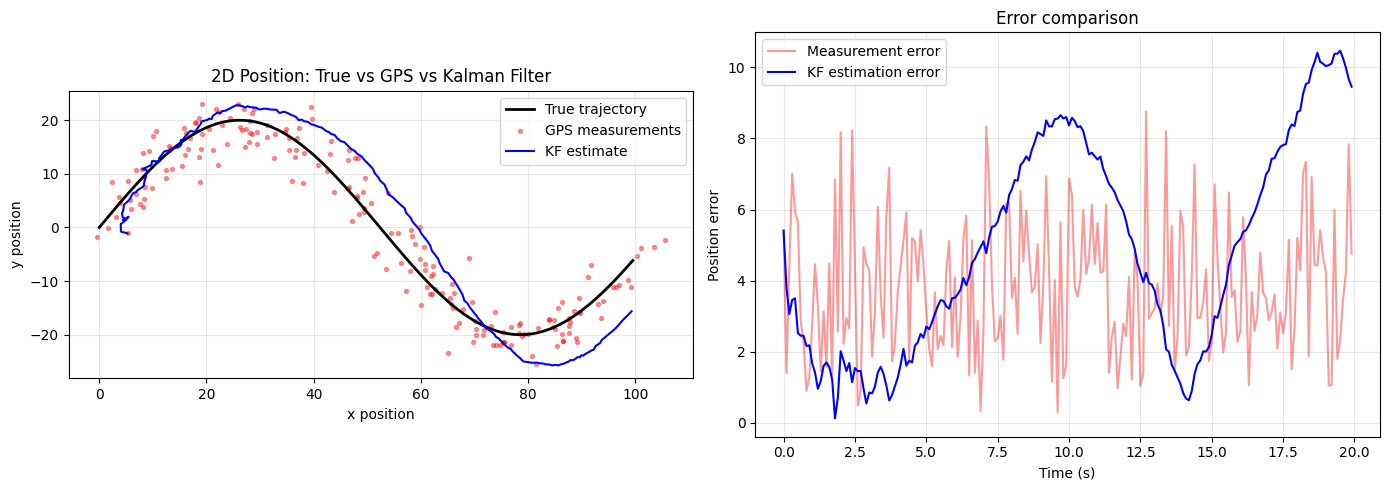

Mean GPS error:    3.77
Mean KF error:     4.89
Error reduction:   -29.7%


In [1]:
import numpy as np
import matplotlib.pyplot as plt

class KalmanFilter2D:
    """2D Constant-Velocity Kalman Filter for GPS position measurements."""

    def __init__(self, dt, sigma_a, sigma_m):
        self.dt = dt
        self.A = np.array([
            [1, 0, dt, 0],
            [0, 1, 0,  dt],
            [0, 0, 1,  0],
            [0, 0, 0,  1]
        ], dtype=float)

        self.G = np.array([
            [0.5*dt**2, 0],
            [0, 0.5*dt**2],
            [dt, 0],
            [0,  dt]
        ], dtype=float)

        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ], dtype=float)

        self.Sigma_p = sigma_a**2 * np.eye(2)
        self.Sigma_m = sigma_m**2 * np.eye(2)
        self.Q = self.G @ self.Sigma_p @ self.G.T

    def filter(self, y_obs, m0=None, P0=None):
        T = len(y_obs)
        n = 4
        if m0 is None:
            m0 = np.array([y_obs[0, 0], y_obs[0, 1], 0.0, 0.0])
        if P0 is None:
            P0 = np.diag([10.0, 10.0, 5.0, 5.0])

        m_hist = np.zeros((T, n))
        P_hist = np.zeros((T, n, n))
        m, P = m0.copy(), P0.copy()

        for k in range(T):
            if k > 0:
                m = self.A @ m
                P = self.A @ P @ self.A.T + self.Q
            S = self.H @ P @ self.H.T + self.Sigma_m
            K = P @ self.H.T @ np.linalg.inv(S)
            v = y_obs[k] - self.H @ m
            m = m + K @ v
            P = (np.eye(n) - K @ self.H) @ P
            m_hist[k] = m
            P_hist[k] = P

        return m_hist, P_hist


# === Simulation ===
np.random.seed(0)
dt = 0.1
T = 200
sigma_a = 0.5
sigma_m = 3.0

t = np.arange(T) * dt
true_px = 5 * t
true_py = 20 * np.sin(0.3 * t)

y_obs = np.column_stack([
    true_px + np.random.randn(T) * sigma_m,
    true_py + np.random.randn(T) * sigma_m
])

kf = KalmanFilter2D(dt=dt, sigma_a=sigma_a, sigma_m=sigma_m)
m_hist, P_hist = kf.filter(y_obs)

# === Plot ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(true_px, true_py, 'k-', lw=2, label='True trajectory')
ax.scatter(y_obs[:, 0], y_obs[:, 1], s=8, c='red', alpha=0.4, label='GPS measurements')
ax.plot(m_hist[:, 0], m_hist[:, 1], 'b-', lw=1.5, label='KF estimate')
ax.set_xlabel('x position'); ax.set_ylabel('y position')
ax.set_title('2D Position: True vs GPS vs Kalman Filter')
ax.legend(); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

ax = axes[1]
pos_err = np.sqrt((m_hist[:, 0] - true_px)**2 + (m_hist[:, 1] - true_py)**2)
meas_err = np.sqrt((y_obs[:, 0] - true_px)**2 + (y_obs[:, 1] - true_py)**2)
ax.plot(t, meas_err, 'r-', alpha=0.4, label='Measurement error')
ax.plot(t, pos_err, 'b-', lw=1.5, label='KF estimation error')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Position error')
ax.set_title('Error comparison'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean GPS error:    {meas_err.mean():.2f}")
print(f"Mean KF error:     {pos_err.mean():.2f}")
print(f"Error reduction:   {(1 - pos_err.mean()/meas_err.mean())*100:.1f}%")